In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [13]:
from sklearn.cluster import KMeans

In [3]:
image_path = '/content/cropped_image.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

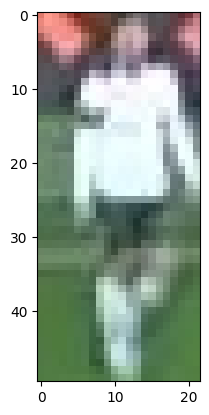

In [4]:
plt.imshow(image)

In [5]:
image_halved = image[0:int(image.shape[0]/2), :]

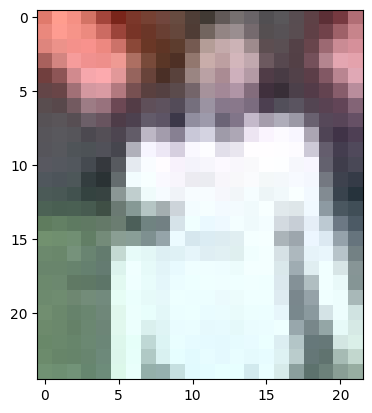

In [7]:
plt.imshow(image_halved)

In [16]:
image_2d = image_halved.reshape(-1, 3)
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(image_2d)

KMeans(n_clusters=2, random_state=0)

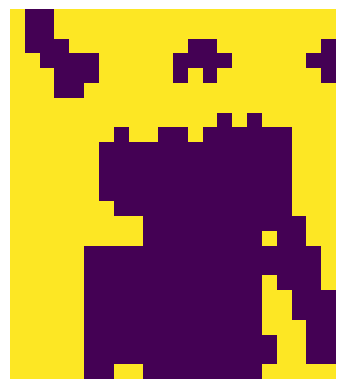

In [18]:
cluster_labels = kmeans.labels_
clustered_img = cluster_labels.reshape(image_halved.shape[0], image_halved.shape[1])
plt.imshow(clustered_img)
plt.axis('off')
plt.show()

In [20]:
corner_cluster = [clustered_img[0,0], clustered_img[0,-1], clustered_img[-1,0], clustered_img[-1,-1]]
non_player_cluster = max(set(corner_cluster), key=corner_cluster.count)
print(non_player_cluster)

1


In [21]:
player_cluster = 1 - non_player_cluster

In [22]:
kmeans.cluster_centers_[player_cluster]

array([227.81568627, 231.50196078, 233.81176471])